# Example 
# pyspectrum - loading spectra.
this example include two types of data files - 
1. **channel-counts**
2. **time-channel** daq collection list mode

In [8]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import pandas as pd

In [1]:
# These are the building blocks of Spectrum that help us work with spectra
# Spectrum - holds the counts, error, channels and calibration. 
# Calibration can be applied on channel or axis 
# AxisCalibration return axis values and ResolutionCalibration returns FWHM or charectherstic width 

from pyspectrum.core import Spectrum
from pyspectrum.calibration import AxisCalibration, ResolutionCalibration

from pyspectrum.calibration.models.hpge_fwhm_model import StandardHPGeFWHMModel

channel- counts type file - 

In [2]:
path = '../Library/152Eu_calsource_10cm_85ks.txt'

spectrum = pd.read_csv(path, names=['counts'])
spectrum['channel'] = spectrum.index 
spectrum['err'] = spectrum["counts"]**0.5

spectrum = Spectrum.from_dataframe(df=spectrum, channel_col="channel", counts_col="counts", counts_error_col="err")

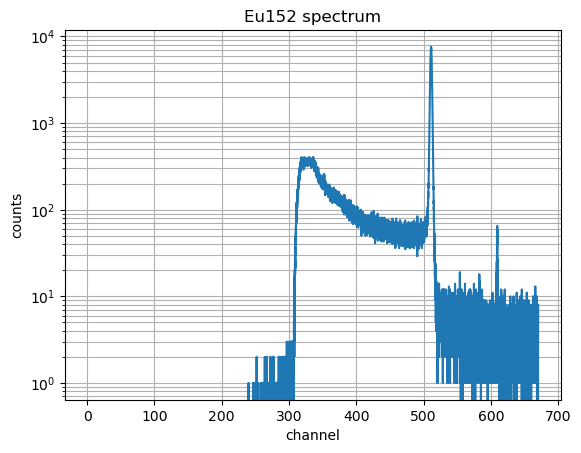

In [10]:
# spectrum data is an xarray which we can plot easily
spectrum.data.plot(yscale='log')

plt.grid(True, which='both')
plt.title('Eu152 spectrum')
plt.xlabel('channel')
plt.ylabel('counts')
plt.show()

# Using time-channel
PySpectrum can convert time-channel list-mode data into a Spectrum in two ways:
- **From a DataFrame** – for data already loaded in memory.
- **From a file** – for large files that are processed lazily in chunks,
  avoiding loading the entire dataset into memory at once.

In [11]:
from pyspectrum.io import TimeChannelParser

In [13]:
path = '../Library/time_channel_to_spectrum.txt'
df_spectrum = pd.read_csv(path, sep=' ', skiprows=5, names=['time','channel','flag'], usecols=[0,1,2])


# known calibration
energy_calib_poly = np.poly1d([0.0408976444, 0.0822321508])
# known resolution
energy_resolution = 1.08 
estimated_FWHM = StandardHPGeFWHMModel().generator((0, energy_resolution/511**0.5, 0))


energy_calib = AxisCalibration(func=energy_calib_poly, name="energy")
res_calib = ResolutionCalibration(func=estimated_FWHM)

spectrum  = TimeChannelParser.from_dataframe(df_spectrum, axis_calib=energy_calib, resolution_calib=res_calib, num_of_channels=16384)

for large files the following is recommended 


In [17]:
lazy_load_spectrum  = TimeChannelParser.from_file(path,
                                                  axis_calib=energy_calib,
                                                  resolution_calib=res_calib,
                                                  num_of_channels=16384, 
                                                  chunk_size=int(10000),
                                                  sep=' ', 
                                                  skiprows=5, 
                                                  names=['time','channel','flag'],
                                                  usecols=[0,1,2])

array([0.        , 0.        , 0.        , ..., 2.23606798, 2.82842712,
       0.        ], shape=(16384,))

Text(0, 0.5, 'counts')

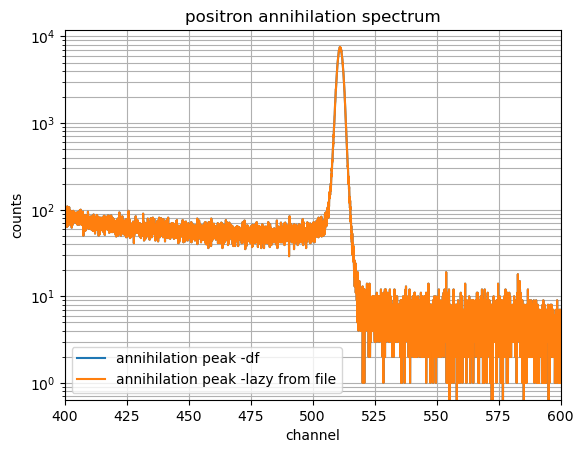

In [22]:
spectrum.data.plot(yscale='log', label='annihilation peak -df')
lazy_load_spectrum.data.plot(yscale='log', label='annihilation peak -lazy from file')

plt.xlim([400,600])
plt.grid(True, which='both')
plt.legend()

plt.title('positron annihilation spectrum')
plt.xlabel('channel')
plt.ylabel('counts')